In [1]:
# Import modules
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import modules for machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [33]:
df = pd.read_csv('data/student_performance.csv')
df.head(4)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14


In [34]:
df.info()
print(df.shape)          # (antall rader, antall kolonner)
print(df.isnull().sum()) # antall manglende verdier per kolonne

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [35]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


G3 er sluttkarakteren (skala 0 til 20). Det er den vi til slutt vil predikere, i hvert fall gjort om til bestått/ikke bestått senere i labben. Ut fra labteksten kommer den inndelingen sannsynligvis i en senere oppgave, så vi holder oss til selve G3 nå.

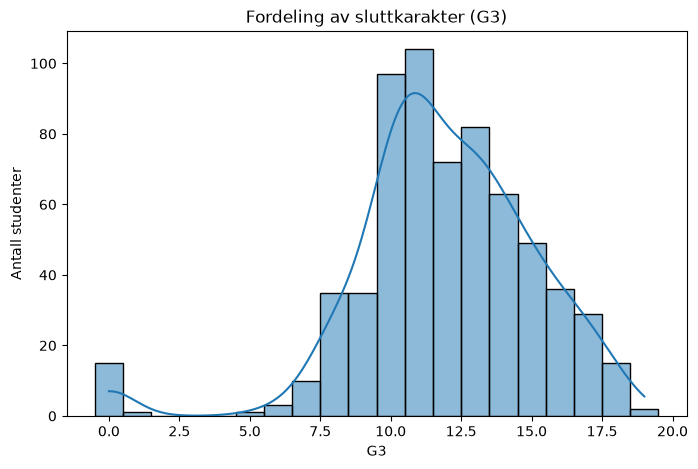

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], discrete=True, kde=True)
plt.title('Fordeling av sluttkarakter (G3)')
plt.xlabel('G3')
plt.ylabel('Antall studenter')
plt.show()

In [45]:
# 1. Gi nye navn til kolonnene
df = df.rename(columns={
    'G1': 'period_1_grades',
    'G2': 'period_2_grades',
    'G3': 'final_grade'
})

# 2. Lag målvariabelen: True hvis final_grade >= 10
df['passed'] = df['final_grade'] >= 10

# Spørsmålet: hvor mange prosent besto?
print(df['passed'].mean() * 100, "har bestått")

84.59167950693374 har bestått


In [42]:
#henter alle numeriske kollonner

numerical_cols = df.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
       'period_1_grades', 'period_2_grades', 'final_grade'],
      dtype='str')


In [44]:
#bygger ny df med numeriske kolonner og "Passed"
df = df[list(numerical_cols) + ['passed']]
print(df.shape)

(649, 17)


In [51]:
#check for missing values
print(df.isnull().sum())

age                0
Medu               0
Fedu               0
traveltime         0
studytime          0
failures           0
famrel             0
freetime           0
goout              0
Dalc               0
Walc               0
health             0
absences           0
period_1_grades    0
period_2_grades    0
final_grade        0
passed             0
dtype: int64


In [52]:
#oppgave 4

# 1. Skill egenskaper (X) fra målvariabelen (y)
X = df.drop(columns=['passed'])
y = df['passed']

# 2. Del i trening (70 %) og test (30 %)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(454, 16) (195, 16)


In [54]:
print(len(X_train), len(X_test))
print(y_train.mean(), y_test.mean())  # begge bør ligge nær 0.84

454 195
0.8458149779735683 0.8461538461538461
